In [36]:
import os
import numpy as np
import easyvvuq as uq
import chaospy as cp
import matplotlib.pyplot as plt
from easyvvuq.actions import CreateRunDirectory, Encode, Decode, ExecuteLocal, Actions
import logging

# EasyVVUQ on many Benchmarks

## Setting up an EasyVVUQ campaign

In [37]:
# Quantity of Interest
QOI = 'energy_uj'

# location where the run directories are stored
WORK_DIR = '.results'

We first set up the `params` dictionary, in which we specify the name, type and default value of each input
Also the `vary` dictionary, which holds the `chaospy` distribution of each input

In [38]:
params = {}
vary = {}

# Current machine maximum number of cores
params['N_THREADS'] = {'type': 'integer', 'default': 16}
vary['N_THREADS'] = cp.DiscreteUniform(1, 16)

# Levels of Clock speed, for our current machine:
# 2200000 = 0,
# 2800000 = 1,
# 3300000 = 2
params['CLK'] = {'type': 'integer', 'default': 2}
vary['CLK'] = cp.DiscreteUniform(0, 2)

# params['POWER_CAP'] = {'type': 'integer', 'default': 220.0}  # power cap in watts

d = len(params)

In [39]:
# input file encoder
encoder = uq.encoders.GenericEncoder(template_fname='energy.template', delimiter='$', target_filename='input.csv')

The wrapper writes a CSV file `output.csv` containing the energy, in microjoules, used during the programs execution.

In [40]:
# CSV output file decoder
decoder = uq.decoders.SimpleCSV(target_filename='output.csv', output_columns=[QOI])

In [41]:
# Local execution of the wrapper around benchmarks
execute = ExecuteLocal(f'{os.getcwd()}/energy_wrapper.py')

Now we are combine all actions we want to execute into an `Actions` object.

In [42]:
# actions to be undertaken: make rundirs, encode input files, execute local model ensemble, decode output files
actions = Actions(
    CreateRunDirectory(root=WORK_DIR, flatten=True),
    Encode(encoder),
    execute,
    Decode(decoder)
)

The central object in the UQ analysis is a so-called Campaign. This is created as:

In [43]:
campaign = uq.Campaign(name='energy', params=params, actions=actions, work_dir=WORK_DIR)

We now select the adaptive Stochastic Collocation sampler. Here

* `polynomial_order = 1`: should be interpreted in the sparse context as starting the sampling plan with a level 1 quadrature rule for all inputs.
* `quadrature_rule='C'`: selects the Clenshaw Curtis quadrature rule.
* `sparse=True`: selects the sparse grid.
* `growth=True`: selects an exponential growth rule which makes the Clenshaw Curtis rule nested.
* `dimension_adaptive=True`: selects the dimension-adaptive sampler.

In [44]:
sampler = uq.sampling.SCSampler(vary=vary, polynomial_order=1, quadrature_rule='discrete', sparse=True, midpoint_level1=True, dimension_adaptive=True)
campaign.set_sampler(sampler)

## Run campaign and adaptation

Run the first ensemble, which consists of just a single sample:

In [45]:
campaign.execute(sequential=True).collate(progress_bar=True)

Running on Glados
Governor set: Done
Frequency set: Done
energy_uj: Stdout: 28313355

Running NONE with 8 threads

energy_uj: Stdout: 28746422
NONE
    Stdout
        Running NONE with 8 threads
        OMP_NUM_THREADS=8
        OMP_PROC_BIND=CLOSE
        OMP_PLACES=CORES
        "Running None"


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 667.56it/s]


To analyse the results (and execute the dimension adaptivity), we need an `SCAnalysis` object:

In [46]:
analysis = uq.analysis.SCAnalysis(sampler=sampler, qoi_cols=[QOI])

In [47]:
# perform analysis (basically estimates moments, Sobol analysis, and updates internal state of analysis)
campaign.apply_analysis(analysis)

Now we'll refine the grid several times in an anisotropic fashion. Here

* `look_ahead`: determines the new admissible candidate refinements.
* `campaign.get_collation_result()`: get the data frame with all code samples.
* `adapt_dimension`: compute the hierarchical surplus at all candidate refinements, and accept the one with the highest surplus.

In [48]:
def refine_sampling_plan(number_of_refinements):
        """
        Refine the sampling plan.

        Parameters
        ----------
        number_of_refinements (int)
           The number of refinement iterations that must be performed.

        Returns
        -------
        None. The new accepted indices are stored in analysis.l_norm and the admissible indices
        in sampler.admissible_idx.
        """
        for i in range(number_of_refinements):
            # compute the admissible indices
            sampler.look_ahead(analysis.l_norm)

            # run the ensemble
            campaign.execute(sequential=True).collate(progress_bar=True)

            # accept one of the multi indices of the new admissible set
            data_frame = campaign.get_collation_result()
            analysis.adapt_dimension(QOI, data_frame)

In [49]:
refine_sampling_plan(20)

Running on Glados
Governor set: Done
Frequency set: Done
energy_uj: Stdout: 43448863

Running NONE with 8 threads

energy_uj: Stdout: 44065180
NONE
    Stdout
        Running NONE with 8 threads
        OMP_NUM_THREADS=8
        OMP_PROC_BIND=CLOSE
        OMP_PLACES=CORES
        "Running None"
Running on Glados
Governor set: Done
Frequency set: Done
energy_uj: Stdout: 60424990

Running NONE with 12 threads

energy_uj: Stdout: 60947562
NONE
    Stdout
        Running NONE with 12 threads
        OMP_NUM_THREADS=12
        OMP_PROC_BIND=CLOSE
        OMP_PLACES=CORES
        "Running None"
Running on Glados
Governor set: Done
Frequency set: Done
energy_uj: Stdout: 70264035

Running NONE with 5 threads

energy_uj: Stdout: 70685706
NONE
    Stdout
        Running NONE with 5 threads
        OMP_NUM_THREADS=5
        OMP_PROC_BIND=CLOSE
        OMP_PLACES=CORES
        "Running None"
Running on Glados
Governor set: Done
Frequency set: Done
energy_uj: Stdout: 79871388

Running NONE with 8 

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 1270.71it/s]
0it [00:00, ?it/s]
/home/mmachado/HPC/energyuq/.venv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/mmachado/HPC/energyuq/.venv/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
0it [00:00, ?it/s]
/home/mmachado/HPC/energyuq/.venv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/mmachado/HPC/energyuq/.venv/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Running on Glados
Governor set: Done
Frequency set: Done
energy_uj: Stdout: 104145370

Running NONE with 3 threads

energy_uj: Stdout: 104578026
NONE
    Stdout
        Running NONE with 3 threads
        OMP_NUM_THREADS=3
        OMP_PROC_BIND=CLOSE
        OMP_PLACES=CORES
        "Running None"
Running on Glados
Governor set: Done
Frequency set: Done
energy_uj: Stdout: 113549456

Running NONE with 14 threads

energy_uj: Stdout: 113932264
NONE
    Stdout
        Running NONE with 14 threads
        OMP_NUM_THREADS=14
        OMP_PROC_BIND=CLOSE
        OMP_PLACES=CORES
        "Running None"
Running on Glados
Governor set: Done
Frequency set: Done
energy_uj: Stdout: 122998537

Running NONE with 12 threads

energy_uj: Stdout: 123475761
NONE
    Stdout
        Running NONE with 12 threads
        OMP_NUM_THREADS=12
        OMP_PROC_BIND=CLOSE
        OMP_PLACES=CORES
        "Running None"
Running on Glados
Governor set: Done
Frequency set: Done
energy_uj: Stdout: 132796141

Running NO

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 2864.31it/s]
/home/mmachado/HPC/energyuq/.venv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/mmachado/HPC/energyuq/.venv/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Running on Glados
Governor set: Done
Frequency set: Done
energy_uj: Stdout: 190585007

Running NONE with 10 threads

energy_uj: Stdout: 191039345
NONE
    Stdout
        Running NONE with 10 threads
        OMP_NUM_THREADS=10
        OMP_PROC_BIND=CLOSE
        OMP_PLACES=CORES
        "Running None"
Running on Glados
Governor set: Done
Frequency set: Done
energy_uj: Stdout: 200273273

Running NONE with 7 threads

energy_uj: Stdout: 200658980
NONE
    Stdout
        Running NONE with 7 threads
        OMP_NUM_THREADS=7
        OMP_PROC_BIND=CLOSE
        OMP_PLACES=CORES
        "Running None"


...

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 1765.28it/s]
/home/mmachado/HPC/energyuq/.venv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/mmachado/HPC/energyuq/.venv/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
0it [00:00, ?it/s]
/home/mmachado/HPC/energyuq/.venv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/mmachado/HPC/energyuq/.venv/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Running on Glados
Governor set: Done
Frequency set: Done
energy_uj: Stdout: 440053048

Running NONE with 1 threads

energy_uj: Stdout: 440444355
NONE
    Stdout
        Running NONE with 1 threads
        OMP_NUM_THREADS=1
        OMP_PROC_BIND=CLOSE
        OMP_PLACES=CORES
        "Running None"
Running on Glados
Governor set: Done
Frequency set: Done
energy_uj: Stdout: 449503716

Running NONE with 16 threads

energy_uj: Stdout: 449883198
NONE
    Stdout
        Running NONE with 16 threads
        OMP_NUM_THREADS=16
        OMP_PROC_BIND=CLOSE
        OMP_PLACES=CORES
        "Running None"


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 1396.47it/s]
/home/mmachado/HPC/energyuq/.venv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/mmachado/HPC/energyuq/.venv/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
0it [00:00, ?it/s]
/home/mmachado/HPC/energyuq/.venv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/mmachado/HPC/energyuq/.venv/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
0it [00:00, ?it/s]
/home/mmachado/HPC/ene

Running on Glados
Governor set: Done
Frequency set: Done
energy_uj: Stdout: 1113666162

Running NONE with 14 threads

energy_uj: Stdout: 1114279396
NONE
    Stdout
        Running NONE with 14 threads
        OMP_NUM_THREADS=14
        OMP_PROC_BIND=CLOSE
        OMP_PLACES=CORES
        "Running None"
Running on Glados
Governor set: Done
Frequency set: Done
energy_uj: Stdout: 1130756754

Running NONE with 3 threads

energy_uj: Stdout: 1131354532
NONE
    Stdout
        Running NONE with 3 threads
        OMP_NUM_THREADS=3
        OMP_PROC_BIND=CLOSE
        OMP_PLACES=CORES
        "Running None"
Running on Glados
Governor set: Done
Frequency set: Done
energy_uj: Stdout: 1147806745

Running NONE with 14 threads

energy_uj: Stdout: 1148343384
NONE
    Stdout
        Running NONE with 14 threads
        OMP_NUM_THREADS=14
        OMP_PROC_BIND=CLOSE
        OMP_PLACES=CORES
        "Running None"
Running on Glados
Governor set: Done
Frequency set: Done
energy_uj: Stdout: 1157982366

Run

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 1296.24it/s]
/home/mmachado/HPC/energyuq/.venv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/mmachado/HPC/energyuq/.venv/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [50]:
campaign.apply_analysis(analysis)
results = campaign.get_last_analysis()

## Analysis of adaptation

The `adaptation_table` shows a plot of that visualizes which inputs got refined at what iteration.

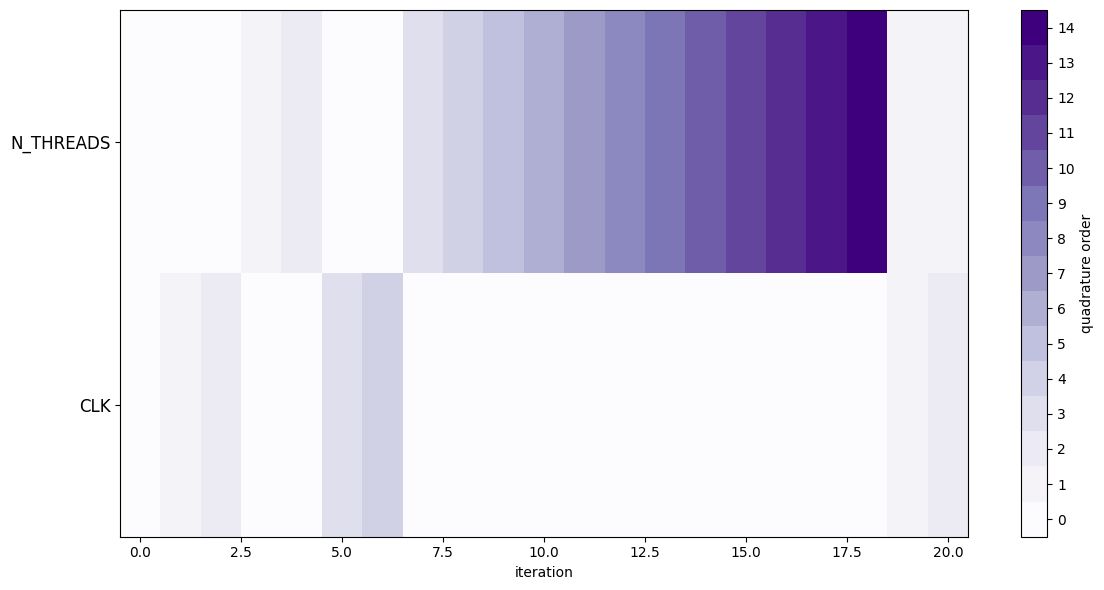

In [51]:
%matplotlib inline
analysis.adaptation_table()

In [52]:
def plot_grid_2D():

    labels = list(campaign.get_active_sampler().vary.get_keys())
    values = list(campaign.get_active_sampler().vary.get_values())
    L = (len(labels)+1)//2
    C = int(np.ceil(np.sqrt((10+1)//2)))
    R = int(np.ceil(L / C))

    fig = plt.figure(figsize=[12,12/C*R])
    
    ax=[]
    ic=0
    for i in range(L-1):
        xd = values[ic*2].upper[0] - values[ic*2].lower[0]
        yd = values[ic*2+1].upper[0] - values[ic*2+1].lower[0]
        ax.append(fig.add_subplot(R, C, ic+1,
                                  xlim=[values[ic*2].lower[0] - xd/10, values[ic*2].upper[0] + xd/10],
                                  ylim=[values[ic*2+1].lower[0] - yd/10, values[ic*2+1].upper[0] + yd/10], 
                                  xlabel=labels[ic*2], ylabel=labels[ic*2+1])
                 )
        ic += 1

    xd = values[ic*2].upper[0] - values[ic*2].lower[0]
    yd = values[ic*2+1].upper[0] - values[ic*2+1].lower[0]
    ax.append(fig.add_subplot(R, C, ic+1,
                              xlim=[values[-2].lower[0] - xd/10, values[-2].upper[0] + xd/10], 
                              ylim=[values[-1].lower[0] - yd/10, values[-1].upper[0] + yd/10], 
                              xlabel=labels[-2], ylabel=labels[-1])
             )

    accepted_grid = sampler.generate_grid(analysis.l_norm)

    ic=0
    for i in range(L-1):
        ax[i].plot(accepted_grid[:,ic*2], accepted_grid[:,ic*2+1], 'o', alpha=0.25)
        ic += 1
    ax[-1].plot(accepted_grid[:,-2], accepted_grid[:,-1], 'o', alpha=0.25)
    
    plt.tight_layout()

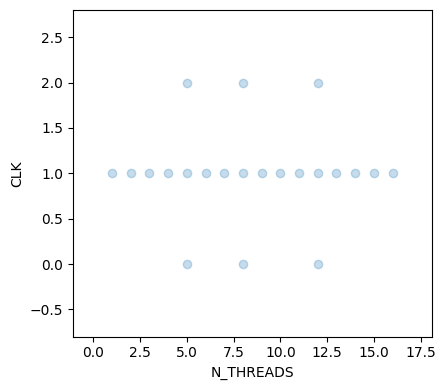

In [53]:
plot_grid_2D()

Since we are dealing with a polynomial test function, the (polynomial) SC approximation should be exact after sufficient iterations. In this case this happens after 10 iterations, and iteration 11 shown above does not improve the surrogate model further. This case be seen by examining the hierarchical surplus error values that were used to accept the multi indices into $\Lambda$. Note that the last two errors are essentially zero:

In [54]:
print(analysis.get_adaptation_errors())

[129114.0, nan, 50450.5, 104203.35714285716, nan, nan, 41112.95454545459, 125307.76623376619, nan, 63215.609098901026, nan, 1686575.9941724935, nan, nan, nan, nan, nan, nan, 63203.0, nan]


In [55]:
analysis.get_pce_sobol_indices(QOI)

(array([462104.73333333]),
 array([5.20965698e+13]),
 {(0,): array([1.14756772e+10]), (1,): array([5.20847054e+13])},
 {(0,): array([0.00022028]), (1,): array([0.99977226])})

In [56]:
def get_confidence_intervals(samples, conf=0.9):
    """
    Compute the confidence intervals given an array of samples

    Parameters
    ----------
    samples : array
        Samples on which to compute the intervals.
    conf : float, optional, must be in [0, 1].
        The confidence interval percentage. The default is 0.9.

    Returns
    -------
    lower : array
        The lower confidence bound..
    upper : array
        The upper confidence bound.

    """

    # ake sure conf is in [0, 1]
    if conf < 0.0 or conf > 1.0:
        print('conf must be specified within [0, 1]')
        return

    # lower bound = alpha, upper bound = 1 - alpha
    alpha = 0.5 * (1.0 - conf)

    # arrays for lower and upper bound of the interval
    n_samples = samples.shape[0]
    N_qoi = samples.shape[1]
    lower = np.zeros(N_qoi)
    upper = np.zeros(N_qoi)

    # the probabilities of the ecdf
    prob = np.linspace(0, 1, n_samples)
    # the closest locations in prob that correspond to the interval bounds
    idx0 = np.where(prob <= alpha)[0][-1]
    idx1 = np.where(prob <= 1.0 - alpha)[0][-1]

    # for every location of qoi compute the ecdf-based confidence interval
    for i in range(N_qoi):
        # the sorted surrogate samples at the current location
        samples_sorted = np.sort(samples[:, i])
        # the corresponding confidence interval
        lower[i] = samples_sorted[idx0]
        upper[i] = samples_sorted[idx1]

    return lower, upper

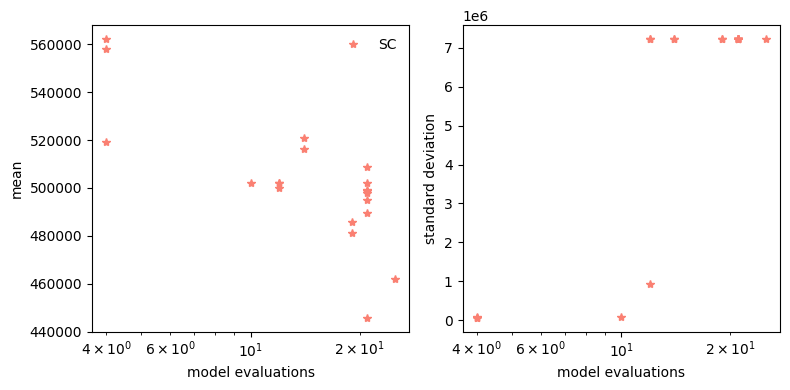

In [57]:
fig = plt.figure(figsize=[8,4])
ax = fig.add_subplot(121, xscale='log', xlabel='model evaluations', ylabel='mean')
ax.plot(np.cumsum(sampler.n_new_points), analysis.mean_history, '*', color='salmon', zorder=3, label='SC')
plt.legend(frameon=False)

ax = fig.add_subplot(122, xscale='log', xlabel='model evaluations', ylabel='standard deviation')
ax.plot(np.cumsum(sampler.n_new_points), np.array(analysis.std_history)**0.5, '*', color='salmon', zorder=3)
plt.tight_layout()

In [58]:
mean_SC = results.describe(QOI, 'mean')
std_SC = results.describe(QOI, 'std')

Finally, we will create a plot with all first-order Sobol indices `S_i`, which shows the fraction of the output variance, that each input variable is responsible for *by itself*. To also estimate higher-order effects (the fraction of variance obtained by simultaneously varying 2 or more inputs together), we sum all first-order indices (shown in the first bar). Where this sum is close to one, there are (almost) no higher-order effects.

In [59]:
def plot_sobols():
    inputs = list(campaign.get_active_sampler().vary.get_keys())
    
    fig = plt.figure()
    ax = fig.add_subplot(111, title=r'First-order Sobol indices', ylim=[0,1])
    ax.set_ylabel(r'$S_i$', fontsize=14)
    
    sobols_first = np.array(list(results.sobols_first(QOI).values()))
    ax.bar(0, np.sum(sobols_first), color='salmon')
    ax.bar(np.arange(1, d+1), sobols_first.flatten(), color='dodgerblue')

    labels = ['Total first order']
    for i in range(d): labels.append(inputs[i])
    ax.set_xticks(np.arange(d+1))
    ax.set_xticklabels(labels, rotation=90)

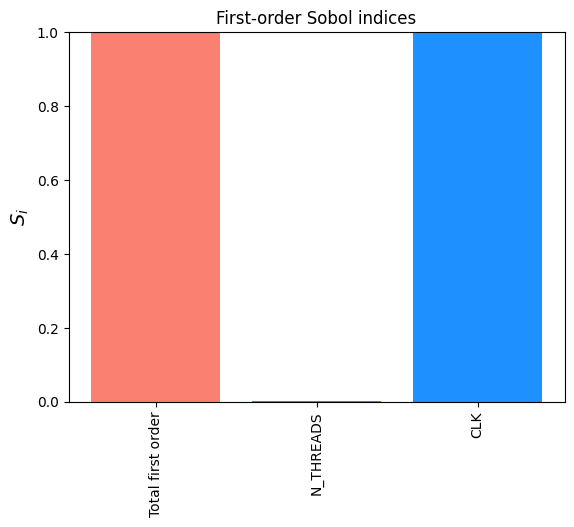

In [60]:
plot_sobols()